# Olist E-Commerce Delivery Performance & Customer Satisfaction Analysis

Code companion to the full write-up in Notion (Ask → Prepare → Process → Analyze → Share).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
orders = pd.read_csv('Data/olist_orders_dataset.csv')
order_items = pd.read_csv('Data/olist_order_items_dataset.csv')
reviews = pd.read_csv('Data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('Data/olist_customers_dataset.csv')
sellers = pd.read_csv('Data/olist_sellers_dataset.csv')

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## Process

### Checking for Null/Missing Values

In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [12]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [14]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [15]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

### Orders vs. Reviews — Initial Check (superseded below)

In [16]:
delivered_orders = orders[orders['order_status'] == 'delivered']
merged_check = delivered_orders.merge(reviews, on='order_id', how='left', indicator=True)
merged_check['_merge'].value_counts()

_merge
both          96361
left_only       646
right_only        0
Name: count, dtype: int64

### Cleaning Checklist — Date Conversion & Validation

In [17]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [18]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [19]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [20]:
(orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']).sum()

np.int64(0)

In [21]:
(orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']).sum()

np.int64(23)

In [22]:
orders[orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31
21338,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30
22520,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14
25393,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25
25646,e37f11cae9985ca58f0b56f268720537,3947a361301f2ff0f3223159a0f2701c,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,63be4feff10a0b1d85f2cfbf10df9754,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18


In [23]:
weird_rows = orders[orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']]
weird_rows[['order_delivered_customer_date', 'order_estimated_delivery_date']]

,order_delivered_customer_date,order_estimated_delivery_date
6437,2017-07-25 19:32:56,2017-08-14
9553,2017-07-06 14:27:51,2017-07-21
13487,2017-07-19 14:13:28,2017-08-08
14474,2017-07-26 18:09:10,2017-08-11
19268,2017-07-20 18:52:41,2017-07-31
21338,2016-10-25 17:51:46,2016-11-30
22520,2017-06-26 15:45:35,2017-07-14
25393,2017-08-10 18:05:38,2017-08-25
25646,2017-07-31 17:49:56,2017-08-24
27470,2017-08-01 21:13:01,2017-08-18


In [24]:
orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [25]:
orders[(orders['order_status'] == 'canceled') & (orders['order_delivered_customer_date'].notnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08


### Excluding Anomalous Rows

In [26]:
rows_to_exclude = (
    (orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())
) | (
    (orders['order_status'] == 'canceled') & (orders['order_delivered_customer_date'].notnull())
) | (
    orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']
)

orders_clean = orders[~rows_to_exclude]

In [27]:
len(orders) - len(orders_clean)

37

In [28]:
print(len(orders))
print(len(orders_clean))
print(rows_to_exclude.sum())

99441
99404
37


### order_items Checks

In [29]:
order_items.duplicated(subset=['order_id', 'order_item_id']).sum()

np.int64(0)

In [30]:
order_items[(order_items['price'] <= 0) | (order_items['freight_value'] < 0)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


### Investigating Duplicate Reviews

In [31]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [32]:
reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

In [33]:
duplicate_order_ids = reviews[reviews['order_id'].duplicated(keep=False)]
duplicate_order_ids.sort_values('order_id').head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


In [34]:
order_items[order_items['order_id'] == '0035246a40f520710769010f752e7507']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
95,0035246a40f520710769010f752e7507,1,8a6187b2665118d5095f99a25fd7ba7a,4a3ca9315b744ce9f8e9374361493884,2017-08-23 01:25:39,87.0,12.11


In [35]:
551 / len(reviews) * 100

0.555309199387245

In [36]:
duplicate_ids = reviews[reviews['order_id'].duplicated(keep=False)]['order_id'].unique()
orders_clean[orders_clean['order_id'].isin(duplicate_ids)]['order_status'].value_counts()

order_status
delivered      525
shipped         11
canceled         4
invoiced         4
unavailable      2
processing       1
Name: count, dtype: int64

In [37]:
sample_check = orders_clean[orders_clean['order_id'].isin(duplicate_ids)]
(sample_check['order_delivered_customer_date'] > sample_check['order_estimated_delivery_date']).mean()

np.float64(0.0712979890310786)

In [38]:
(orders_clean['order_delivered_customer_date'] > orders_clean['order_estimated_delivery_date']).mean()

np.float64(0.07872922618808097)

In [39]:
reviews_clean = reviews.sort_values('review_answer_timestamp', ascending=False).drop_duplicates(subset='order_id', keep='first')

In [40]:
len(reviews) - len(reviews_clean)

551

### Customers & Sellers Validation

In [41]:
valid_states = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS',
                 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC',
                 'SP', 'SE', 'TO']

customers[~customers['customer_state'].isin(valid_states)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [42]:
sellers[~sellers['seller_state'].isin(valid_states)]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [43]:
customers['customer_id'].duplicated().sum()
sellers['seller_id'].duplicated().sum()

np.int64(0)

### Merge Chain

In [44]:
step1 = orders_clean.merge(order_items, on='order_id', how='inner')
print(len(orders_clean), len(step1))

99404 112585


In [45]:
step2 = step1.merge(reviews_clean, on='order_id', how='left')
print(len(step1), len(step2))

112585 112585


In [46]:
step3 = step2.merge(customers, on='customer_id', how='left')
print(len(step2), len(step3))

112585 112585


In [47]:
step4 = step3.merge(sellers, on='seller_id', how='left')
print(len(step3), len(step4))

112585 112585


## Analyze

### Building order_level

In [48]:
order_level = step4.drop_duplicates(subset='order_id').copy()
print(len(order_level))

98629


In [49]:
order_level = order_level[order_level['order_status'] == 'delivered'].copy()

In [50]:
order_level['delay_days'] = (order_level['order_delivered_customer_date'] - order_level['order_estimated_delivery_date']).dt.days

In [51]:
order_level['delay_days'].describe()

count    96447.000000
mean       -11.872884
std         10.179730
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

In [52]:
orders_clean['order_id'].nunique()

99404

In [53]:
order_level['order_id'].nunique()

96447

In [54]:
missing_orders = orders_clean[~orders_clean['order_id'].isin(order_level['order_id'])]
len(missing_orders)
missing_orders['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

### Delay vs. Review Score

In [55]:
order_level['was_late'] = order_level['delay_days'] > 0
order_level.groupby('was_late')['review_score'].mean()

was_late
False    4.290774
True     2.270491
Name: review_score, dtype: float64

In [56]:
def bucket_delay(days):
    if days <= 0:
        return 'On-time or early'
    elif days <= 3:
        return '1-3 days late'
    elif days <= 7:
        return '4-7 days late'
    elif days <= 14:
        return '8-14 days late'
    else:
        return '15+ days late'

order_level['delay_bucket'] = order_level['delay_days'].apply(bucket_delay)

In [57]:
bucket_order = ['On-time or early', '1-3 days late', '4-7 days late', '8-14 days late', '15+ days late']
order_level.groupby('delay_bucket')['review_score'].mean().reindex(bucket_order)

delay_bucket
On-time or early    4.290774
1-3 days late       3.291037
4-7 days late       2.102975
8-14 days late      1.670816
15+ days late       1.723596
Name: review_score, dtype: float64

In [58]:
order_level['delay_bucket'].value_counts().reindex(bucket_order)

delay_bucket
On-time or early    89913
1-3 days late        1870
4-7 days late        1802
8-14 days late       1478
15+ days late        1384
Name: count, dtype: int64

### Delivery Performance by State

In [59]:
order_level.groupby('customer_state')[['delay_days', 'review_score']].mean().sort_values('delay_days', ascending=False)

,delay_days,review_score
customer_state,,
AL,-8.707809,3.847716
MA,-9.571827,3.832865
SE,-10.020896,3.907186
ES,-10.496241,4.078720
BA,-10.794533,3.930629
CE,-10.804535,3.944226
MS,-11.052782,4.161660
SP,-11.071097,4.246199
PI,-11.306723,3.993631


In [60]:
state_summary = order_level.groupby('customer_state').agg(
    order_count=('order_id', 'count'),
    pct_late=('was_late', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values('pct_late', ascending=False)

state_summary

,order_count,pct_late,avg_review
customer_state,,,
AL,397,0.214106,3.847716
MA,717,0.174338,3.832865
SE,335,0.152239,3.907186
PI,476,0.138655,3.993631
CE,1279,0.137608,3.944226
RR,41,0.121951,3.902439
BA,3256,0.121622,3.930629
RJ,12349,0.121062,3.965684
PA,946,0.112051,3.914255


### Delivery Performance by Seller

In [61]:
seller_summary = order_level.groupby('seller_id').agg(
    order_count=('order_id', 'count'),
    pct_late=('was_late', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values('pct_late', ascending=False)

seller_summary

,order_count,pct_late,avg_review
seller_id,,,
f5fea3ffed6c2e889bab72705557c63a,1,1.0,5.000000
5ca5d579b5857ee8709479b1047cecc3,1,1.0,1.000000
ebe3dabc4955c9b0d695e7bda38bf5c3,1,1.0,3.000000
685b870da5b52a710782c9c0fefbeb5b,2,1.0,2.000000
6524b847b982cd56bb5d4b02b776ee42,1,1.0,4.000000
...,...,...,...
fad44952713764836814be105382aee5,31,0.0,4.354839
fac35d150712afb921ec59ac5f39bb11,5,0.0,4.400000
fac1a9017ade7bdc94058fc1c969f355,9,0.0,4.666667


In [62]:
seller_summary.sort_values('order_count', ascending=False).head(20)

,order_count,pct_late,avg_review
seller_id,,,
6560211a19b47992c3666cc44a7e94c0,1809,0.052515,3.985515
4a3ca9315b744ce9f8e9374361493884,1726,0.099652,3.885764
cc419e0650a3c5ba77189a1882b7556a,1648,0.052791,4.154501
1f50f920176fa81dab994f9023523100,1384,0.089595,4.155185
da8622b14eb17ae2831f4ac5b9dab84a,1294,0.067233,4.192547
955fee9216a65b617aa5c0531780ce60,1255,0.061355,4.206897
7a67c85e85bb2ce8582c35f2203ad736,1135,0.052863,4.295475
ea8482cd71df3c1969d7b9473ff13abc,1122,0.085561,4.044803
4869f7a5dfa277a7dca6462dcf3b52b2,1117,0.105640,4.164112


In [63]:
len(seller_summary)

2959

In [64]:
print(len(seller_summary))
print((seller_summary['order_count'] >= 20).sum())
print((seller_summary['order_count'] >= 50).sum())
print((seller_summary['order_count'] >= 100).sum())

2959
794
419
207


In [65]:
reliable_sellers = seller_summary[seller_summary['order_count'] >= 50]
reliable_sellers.sort_values('pct_late', ascending=False).head(15)

,order_count,pct_late,avg_review
seller_id,,,
54965bbe3e4f07ae045b90b0b8541f52,72,0.305556,3.176471
beadbee30901a7f61d031b6b686095ad,63,0.238095,3.936508
a49928bcdf77c55c6d6e05e09a9b4ca5,94,0.223404,3.063830
712e6ed8aa4aa1fa65dab41fed5737e4,77,0.207792,3.394737
06a2c3af7b3aee5d69171b0e14f0ee87,388,0.190722,4.018229
ea566164622c6b439516ab18062c42cd,50,0.180000,3.780000
d20b021d3efdf267a402c402a48ea64b,78,0.179487,3.831169
6039e27294dc75811c0d8a39069f52c0,62,0.177419,3.741935
88460e8ebdecbfecb5f9601833981930,238,0.176471,3.443038


## Share — Visualizations

In [66]:
bucket_avg = order_level.groupby('delay_bucket')['review_score'].mean().reindex(bucket_order)

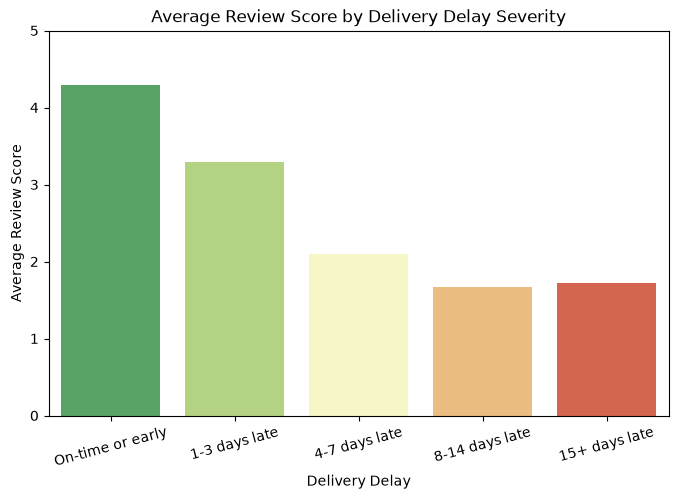

In [67]:
plt.figure(figsize=(8, 5))
sns.barplot(x=bucket_avg.index, y=bucket_avg.values, hue=bucket_avg.index, palette='RdYlGn_r', legend=False)
plt.title('Average Review Score by Delivery Delay Severity')
plt.xlabel('Delivery Delay')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.show()

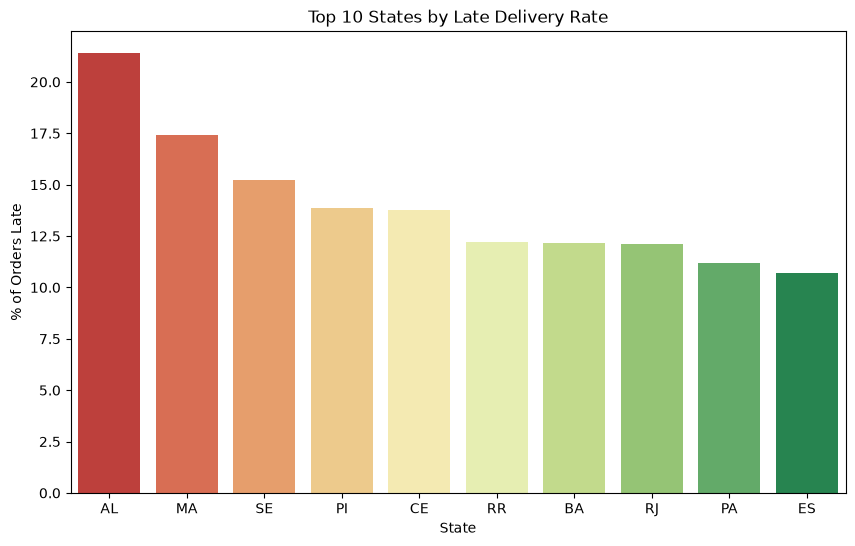

In [68]:
top10_states = state_summary.sort_values('pct_late', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_states.index, y=top10_states['pct_late'] * 100, hue=top10_states.index, palette='RdYlGn', legend=False)
plt.title('Top 10 States by Late Delivery Rate')
plt.xlabel('State')
plt.ylabel('% of Orders Late')
plt.show()

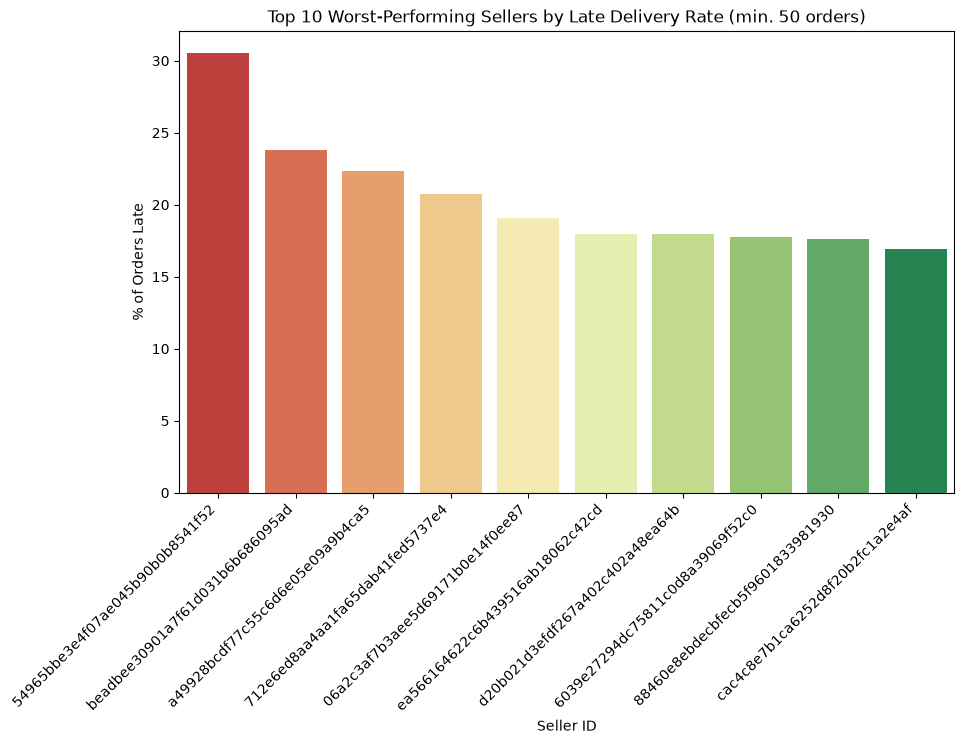

In [70]:
top_worst_sellers = reliable_sellers.sort_values('pct_late', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_worst_sellers.index, y=top_worst_sellers['pct_late'] * 100, hue=top_worst_sellers.index, palette='RdYlGn', legend=False)
plt.title('Top 10 Worst-Performing Sellers by Late Delivery Rate (min. 50 orders)')
plt.xlabel('Seller ID')
plt.ylabel('% of Orders Late')
plt.xticks(rotation=45, ha='right')
plt.show()